In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import pyagrum as gum
import pyagrum.lib.notebook as gnb
from IPython.display import display, HTML
import warnings
from tqdm import tqdm

sys.path.insert(0, str(Path().resolve().parents[1]))
from src.config import *  # noqa
from src.utils import *  # noqa
from src.mosaic import *  # noqa

In [21]:
# Read config file
config = load_config("conf.yaml")

# Results folder: a single one for the whole hyperparameter grid (see
# exp.py) -- each row of df_tot.csv already carries its own
# n_clients/ess/prob_shift/alpha combination.
res_path = Path(config["res_path"])

# Read results (all weighting schemas x all grid combinations, one row per
# (n_clients, ess, prob_shift, alpha, size, rep))
df_tot = pd.read_csv(res_path / f"df_tot.csv")

In [22]:
# Compute mean across repetitions, grouped by every grid hyperparameter AND
# size (not just size -- otherwise different hyperparameter combinations
# would get silently averaged together). The intersection ratio gets its own
# MEDIAN (not mean) plus Q1/Q3: Q1 <= median <= Q3 always holds by
# construction, but NOT for the mean when the distribution is skewed
# (intersection_frac piles up near 1.0 with an occasional low outlier rep,
# which pulls the mean below Q1 -- verified on real data). Pairing the mean
# with an IQR band would be a mismatched pair of statistics; median+IQR is
# the consistent, non-parametric choice (and mirrors PriorCN.compute, which
# already summarizes each repetition via a median across mechanisms).
group_cols = ["n_clients", "ess", "prob_shift", "alpha", "size"]
df_mean = df_tot.drop(columns="rep").groupby(group_cols, as_index=False).mean()
df_mean["intersection_frac_median"] = (
    df_tot.groupby(group_cols)["intersection_frac"].median().to_numpy()
)
df_mean["intersection_frac_q1"] = (
    df_tot.groupby(group_cols)["intersection_frac"].quantile(0.25).to_numpy()
)
df_mean["intersection_frac_q3"] = (
    df_tot.groupby(group_cols)["intersection_frac"].quantile(0.75).to_numpy()
)
df_mean.head()

,n_clients,ess,prob_shift,alpha,size,mle,idm_min,idm_mean,idm_max,mos_w1_min,...,mos_w2_min,mos_w2_mean,mos_w2_max,mos_w3_min,mos_w3_mean,mos_w3_max,intersection_frac,intersection_frac_median,intersection_frac_q1,intersection_frac_q3
0,5,2,0.0,10,5,0.122527,0.159538,0.163603,0.392325,0.081785,...,0.086915,0.099996,0.206103,0.078958,0.088328,0.186961,1.0000,1.0000,1.00000,1.00000
1,5,2,0.0,10,55,0.014608,0.021203,0.023574,0.058076,0.011735,...,0.012887,0.013696,0.024912,0.011775,0.012132,0.019634,1.0000,1.0000,1.00000,1.00000
2,5,2,0.0,10,105,0.009146,0.010895,0.012693,0.029178,0.006848,...,0.007222,0.007394,0.011422,0.006897,0.007060,0.010101,0.9375,0.9375,0.90625,0.96875
3,5,2,0.5,10,5,0.122527,0.159538,0.163603,0.392325,0.083484,...,0.086868,0.099108,0.206445,0.080680,0.090005,0.191914,1.0000,1.0000,1.00000,1.00000
4,5,2,0.5,10,55,0.014608,0.021203,0.023574,0.058076,0.012401,...,0.013329,0.014081,0.026973,0.012075,0.012549,0.019703,0.9375,0.9375,0.90625,0.96875


In [23]:
sns.reset_defaults()
plt.style.use("seaborn-v0_8-paper")

plt.rcParams.update(
    {
        # ---- base ----
        "figure.figsize": [7, 4],
        "font.size": 9,
        # ---- axes ----
        "axes.labelsize": 10,
        "axes.titlesize": 11,
        "axes.linewidth": 0.8,
        "axes.edgecolor": "black",
        # ---- legend ----
        "legend.fontsize": 10,
        # "legend.labelspacing": 0.3,
        # ---- ticks ----
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "xtick.major.width": 0.6,
        "ytick.major.width": 0.6,
        # ---- lines ----
        "lines.linewidth": 1.0,
        # ---- dpi ----
        "figure.dpi": 300,
        "savefig.dpi": 300,
        # # ---- tex ----
        # "text.usetex": True,
    }
)

In [24]:
# Facet grid: rows = (n_clients, ess) combinations, columns = (prob_shift,
# alpha) combinations. With single-value lists in conf.yaml (the default),
# this is just a 1x1 grid.
row_vals = sorted(set(df_mean[["n_clients", "ess"]].itertuples(index=False, name=None)))
col_vals = sorted(
    set(df_mean[["prob_shift", "alpha"]].itertuples(index=False, name=None))
)
print(
    f"Grid: {len(row_vals)} row(s) (n_clients, ess) x {len(col_vals)} col(s) (prob_shift, alpha)"
)

Grid: 4 row(s) (n_clients, ess) x 3 col(s) (prob_shift, alpha)


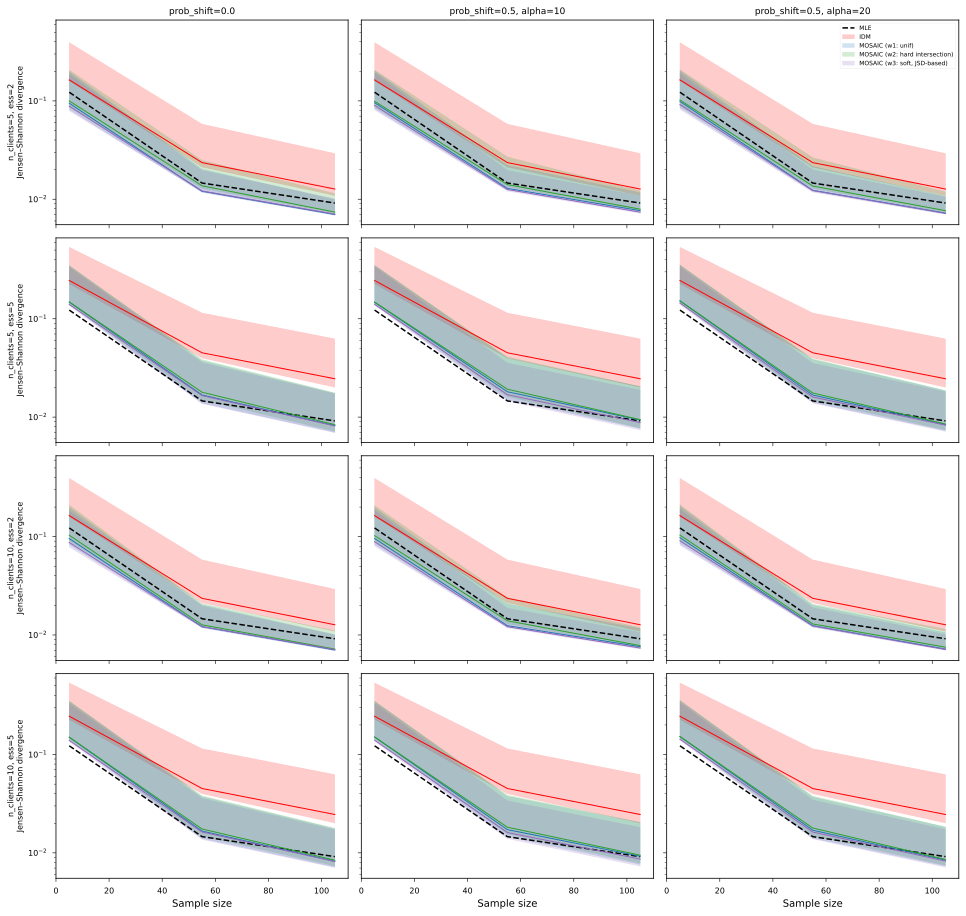

In [25]:
# Plot: one panel per (n_clients, ess) x (prob_shift, alpha) combination.
mos_colors = {1: "tab:blue", 2: "tab:green", 3: "tab:purple"}
mos_labels = {
    1: "MOSAIC (w1: unif)",
    2: "MOSAIC (w2: hard intersection)",
    3: "MOSAIC (w3: soft, JSD-based)",
}

fig, axes = plt.subplots(
    len(row_vals),
    len(col_vals),
    figsize=(4.5 * len(col_vals), 3.2 * len(row_vals)),
    squeeze=False,
    sharex=True,
    sharey=True,
)

for i, (nc, ess) in enumerate(row_vals):
    for j, (p, a) in enumerate(col_vals):
        ax = axes[i][j]
        sub = df_mean[
            (df_mean["n_clients"] == nc)
            & (df_mean["ess"] == ess)
            & (df_mean["prob_shift"] == p)
            & (df_mean["alpha"] == a)
        ].sort_values("size")

        ax.plot(
            sub["size"], sub["mle"], "--", linewidth=1.5, color="black", label="MLE"
        )
        ax.fill_between(
            sub["size"],
            sub["idm_min"],
            sub["idm_max"],
            color="red",
            alpha=0.2,
            label="IDM",
        )
        ax.plot(sub["size"], sub["idm_mean"], color="red")
        for w, color in mos_colors.items():
            ax.fill_between(
                sub["size"],
                sub[f"mos_w{w}_min"],
                sub[f"mos_w{w}_max"],
                color=color,
                alpha=0.2,
                label=mos_labels[w],
            )
            ax.plot(sub["size"], sub[f"mos_w{w}_mean"], color=color)

        ax.set_yscale("log")
        if i == 0:
            title = f"prob_shift={p}, alpha={a}" if p!=0 else f"prob_shift={p}"
            ax.set_title(title, fontsize=9)
        if j == 0:
            ax.set_ylabel(
                f"n_clients={nc}, ess={ess}\nJensen–Shannon divergence", fontsize=8
            )
        if i == len(row_vals) - 1:
            ax.set_xlabel("Sample size")

axes[0][-1].legend(loc="upper right", fontsize=6)

plt.tight_layout()
plt.show()

# Save figure
fig.savefig(f"{res_path}.svg", dpi=1200, bbox_inches="tight", transparent=False)

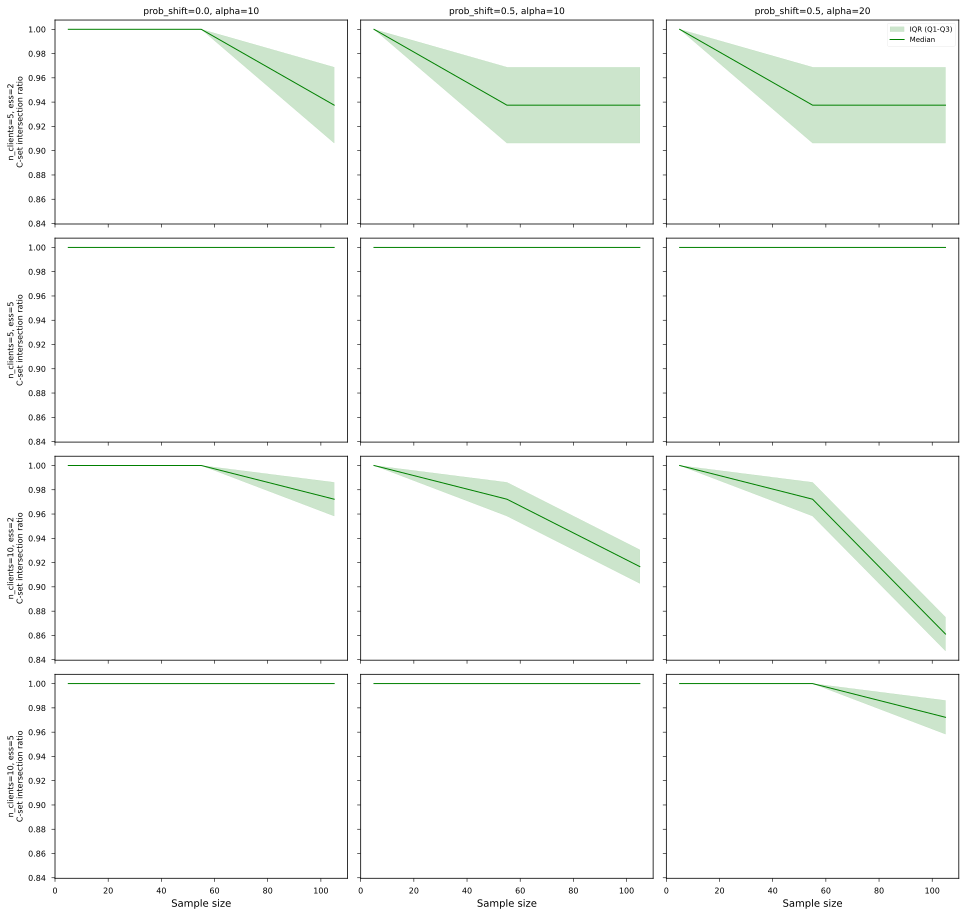

In [26]:
# Plot: intersection ratio, one panel per grid combination. Meaningful for
# weighting=2 (hard intersection); computed and available for all schemas
# since it only depends on the target/candidates' own credal sets, not on
# the weighting formula (see exp.py).
fig, axes = plt.subplots(
    len(row_vals),
    len(col_vals),
    figsize=(4.5 * len(col_vals), 3.2 * len(row_vals)),
    squeeze=False,
    sharex=True,
    sharey=True,
)

for i, (nc, ess) in enumerate(row_vals):
    for j, (p, a) in enumerate(col_vals):
        ax = axes[i][j]
        sub = df_mean[
            (df_mean["n_clients"] == nc)
            & (df_mean["ess"] == ess)
            & (df_mean["prob_shift"] == p)
            & (df_mean["alpha"] == a)
        ].sort_values("size")

        ax.fill_between(
            sub["size"],
            sub["intersection_frac_q1"],
            sub["intersection_frac_q3"],
            color="green",
            alpha=0.2,
            label="IQR (Q1-Q3)",
        )
        ax.plot(
            sub["size"], sub["intersection_frac_median"], color="green", label="Median"
        )

        if i == 0:
            ax.set_title(f"prob_shift={p}, alpha={a}", fontsize=9)
        if j == 0:
            ax.set_ylabel(
                f"n_clients={nc}, ess={ess}\nC-set intersection ratio", fontsize=8
            )
        if i == len(row_vals) - 1:
            ax.set_xlabel("Sample size")

axes[0][-1].legend(loc="upper right", fontsize=7)

plt.tight_layout()
plt.show()

# Save figure
fig.savefig(
    f"{res_path}_intersection.svg", dpi=1200, bbox_inches="tight", transparent=False
)

## Loading a saved model (`results/models/<task_id>.pkl`)

Reference example for reading back a model saved by `exp.py`. This is the pattern the global optimization phase will use to get $\theta^i_{X|\pi_X} \in K^{i+}_{X|\pi_X}$ from the saved, updated credal sets. **Always go through `lookup_cpt_row`**, never `cpt.topandas()` or a hand-rolled row index (see `snapshot_cpts`/`lookup_cpt_row` in `src/utils.py` for why).

Models are archived **one file per task** (`results/models/<n_clients>_<ess>_<prob_shift>_<alpha>_<size>_<rep>.pkl`, see `exp.py`'s `_model_filename`) instead of a single `models.pkl` for the whole grid. Saving is also off by default for a plain local-learning-and-update sweep (`save_models: false` in `conf.yaml`) since models are only needed for the global optimization phase; this demo only works when a run had `save_models: true`.

In [27]:
import pickle
from src.utils import lookup_cpt_row

models_dir = res_path / "models"
model_files = sorted(models_dir.glob("*.pkl"))
print(f"{len(model_files)} saved models found in {models_dir}")

# The filename itself IS the task_id (n_clients, ess, prob_shift, alpha, size, rep).
model_path = model_files[0]
print(
    "Example task_id (n_clients, ess, prob_shift, alpha, size, rep):", model_path.stem
)

with open(model_path, "rb") as f:
    model = pickle.load(f)
print("Available model kinds:", sorted(model.keys()))

# Read P(Cancer | Pollution, Smoker) from client 0's MOSAIC-updated credal
# set (weighting=3, lower bound), for one specific parent configuration.
entry = model["mos_w3_min"]["C"]
print("\nC's parent configurations (row order):", entry["parents"])
print("C's own category labels (column order):", entry["labels"])

row = lookup_cpt_row(entry, parents={"P": "low", "S": "True"})
print(
    "\nP(C | P=low, S=True)  [MOSAIC w3, lower bound] =",
    dict(zip(entry["labels"], row)),
)

# A root variable (no parents) is read the same way, with parents=None.
entry_p = model["bn_mle"]["P"]
print(
    "P(Pollution)  [client 0's exact MLE] =",
    dict(zip(entry_p["labels"], lookup_cpt_row(entry_p))),
)

72 saved models found in results/models
Example task_id (n_clients, ess, prob_shift, alpha, size, rep): 10_2_0.0_10_105_0
Available model kinds: ['bn_mle', 'idm_max', 'idm_min', 'mos_w1_max', 'mos_w1_min', 'mos_w2_max', 'mos_w2_min', 'mos_w3_max', 'mos_w3_min', 'prior_w1_max', 'prior_w1_min', 'prior_w2_max', 'prior_w2_min', 'prior_w3_max', 'prior_w3_min']

C's parent configurations (row order): [{'P': 'low', 'S': 'True'}, {'P': 'high', 'S': 'True'}, {'P': 'low', 'S': 'False'}, {'P': 'high', 'S': 'False'}]
C's own category labels (column order): ['True', 'False']

P(C | P=low, S=True)  [MOSAIC w3, lower bound] = {'True': np.float64(0.03015699044476339), 'False': np.float64(0.9656773581785401)}
P(Pollution)  [client 0's exact MLE] = {'low': np.float64(0.9047619047619048), 'high': np.float64(0.09523809523809523)}
